## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [283]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [284]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends (1).csv')
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [285]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [286]:
# TODO: drop the Customer ID column  
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [287]:
df1 = df.drop('Customer ID', axis=1)
df1

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [288]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [289]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [290]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [291]:
# TODO: univariate — describe numeric columns
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [292]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?

male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

In [293]:
print('Male:', male_df.shape)

print('Female:', female_df.shape)


Male: (2652, 19)
Female: (1248, 19)


## **EDA**

### **Item Purchased**

In [294]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_items = male_df['Item Purchased'].value_counts().reset_index()
female_items = female_df['Item Purchased'].value_counts().reset_index()
all_items = df['Item Purchased'].value_counts().reset_index()

In [295]:
print('Male:')
print(male_items.head())

print('\nFemale:')
print(female_items.head())

print('\nAll customers:')
print(all_items.head())

Male:
  Item Purchased  count
0          Pants    123
1        Jewelry    119
2          Dress    114
3           Coat    114
4        Sweater    114

Female:
  Item Purchased  count
0         Blouse     66
1          Shirt     59
2        Sandals     59
3        Handbag     58
4          Socks     58

All customers:
  Item Purchased  count
0         Blouse    171
1          Pants    171
2        Jewelry    171
3          Shirt    169
4          Dress    166


In [296]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
#     legend=?
# )
# plt.title?
# plt.xlabel?
# plt.ylabel?
# plt.show()

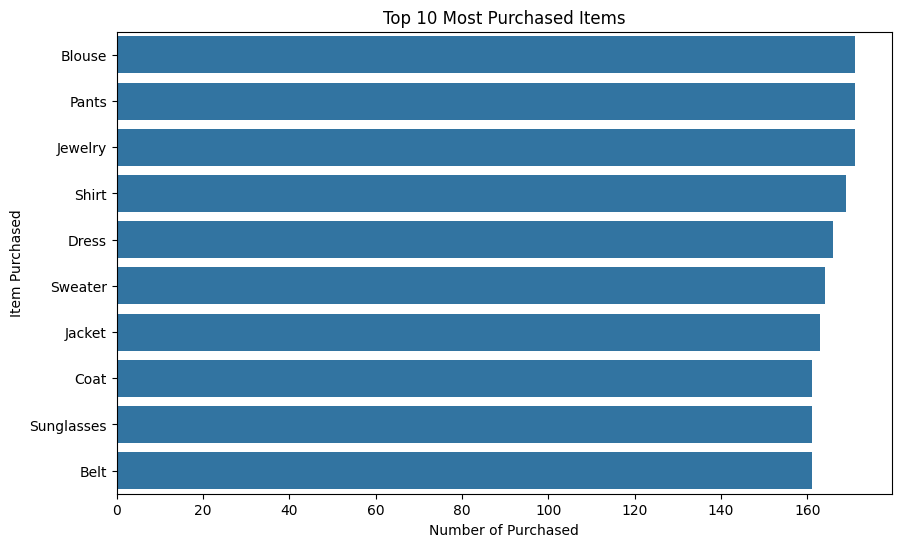

In [297]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=all_items.head(10),
    x='count',
    y='Item Purchased',
    legend=False
)

plt.title('Top 10 Most Purchased Items')
plt.xlabel('Number of Purchased')
plt.ylabel('Item Purchased')
plt.show()

In [298]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
# )
# plt.title("Top 10 Purchased Items by Males")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()

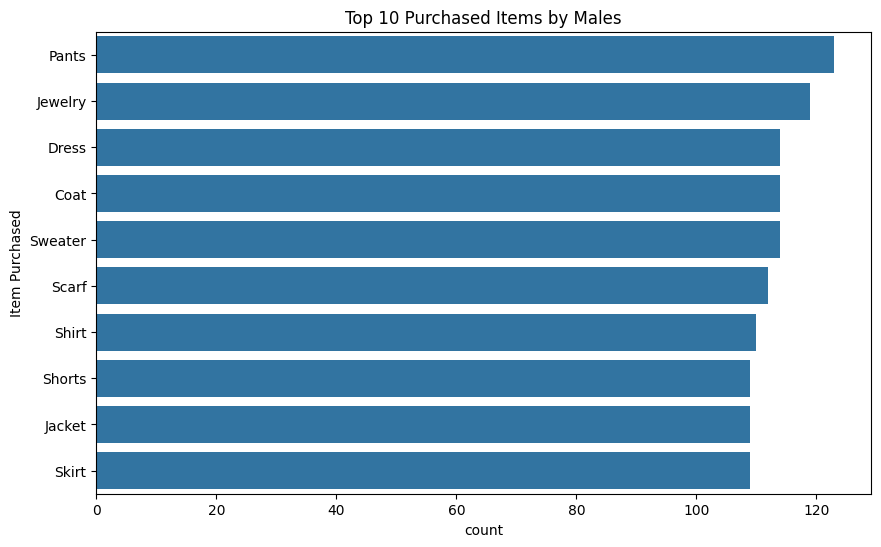

In [299]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=male_items.head(10),
    x='count',
    y='Item Purchased'
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [300]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_item_f.head(10),
#     y='Item Purchased',
#     x='count',
#     hue='Item Purchased',
#     dodge=False,
#     legend=False
# )
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()

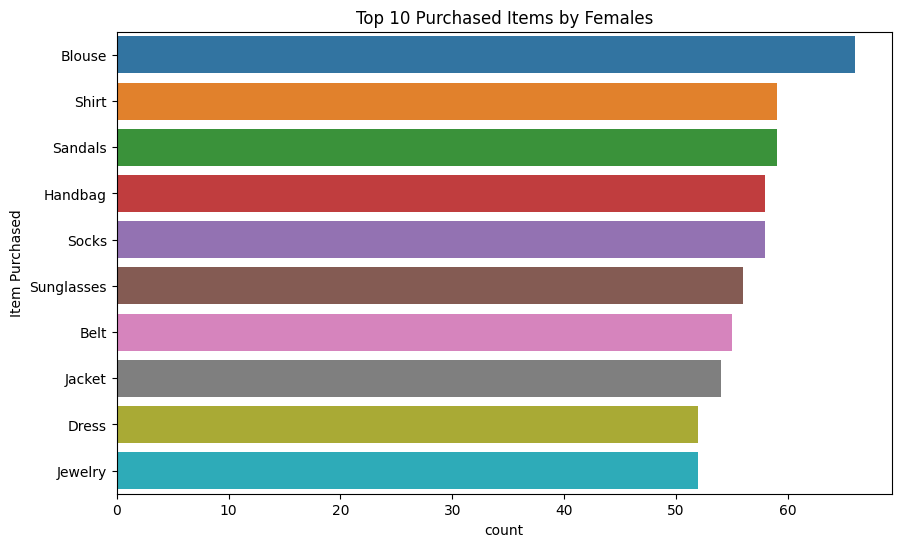

In [301]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=female_items.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [302]:
# TODO: count Size with value_counts() for all customers
all_customers = df['Size'].value_counts().reset_index()
all_customers

,Size,count
0,M,1755
1,L,1053
2,S,663
3,XL,429


In [303]:
# TODO: count Size with value_counts() for male_df and female_df
male_size = male_df['Size'].value_counts().reset_index()
female_size = female_df['Size'].value_counts().reset_index()


In [304]:
print("Size Male:")
print(male_size)

print("\nSize Female:")
print(female_size)



Size Male:
  Size  count
0    M   1165
1    L    716
2    S    476
3   XL    295

Size Female:
  Size  count
0    M    590
1    L    337
2    S    187
3   XL    134


### **Category**

In [305]:
df['Category']
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [306]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df['Category'].value_counts().reset_index()
ctg


,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [307]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
male_ctg = male_df['Category'].value_counts().reset_index()
female_ctg = female_df['Category'].value_counts().reset_index()


In [308]:
print('Male:')
print(male_ctg)

print('\nFemale:')
print(female_ctg)



Male:
      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223

Female:
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


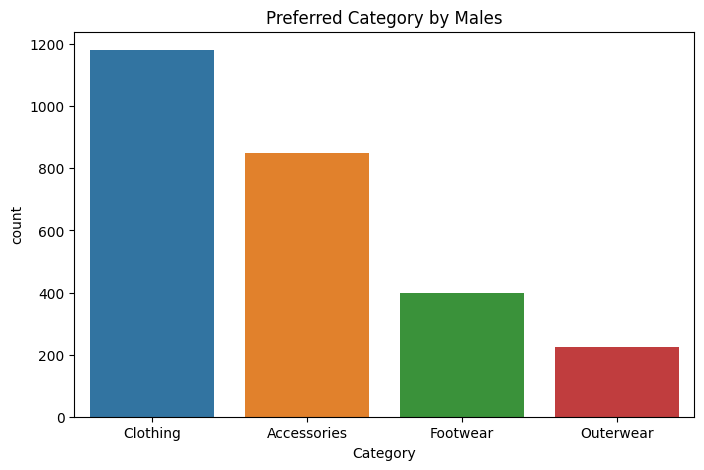

In [309]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data = male_ctg,
    x='Category',
    y= 'count',
    hue='Category'
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

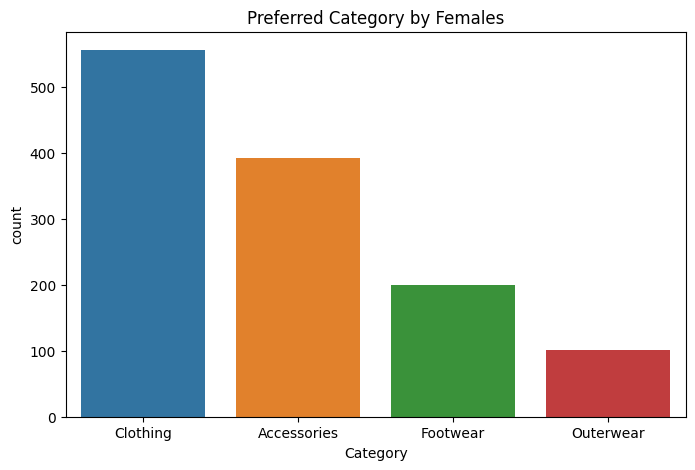

In [310]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data = female_ctg,
   x ='Category',
   y = 'count',
   hue='Category',
   dodge=False,
   legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

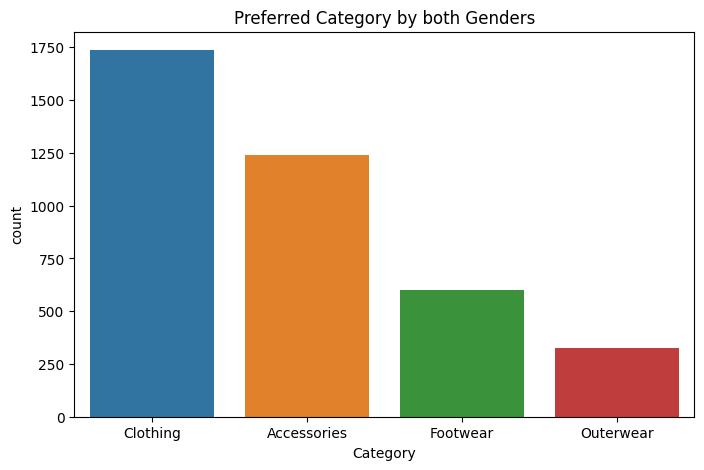

In [311]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [312]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()


In [313]:
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


In [314]:
print('Waffle_male')
print(waffle_data_m)

print('\nWafflm_female')
print(waffle_data_f)



Waffle_male
{'Clothing': np.int64(1181), 'Accessories': np.int64(848), 'Footwear': np.int64(400), 'Outerwear': np.int64(223)}

Wafflm_female
{'Clothing': np.int64(556), 'Accessories': np.int64(392), 'Footwear': np.int64(199), 'Outerwear': np.int64(101)}


In [315]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()

In [316]:
female_ctg['Category']
female_ctg

,Category,count
0,Clothing,556
1,Accessories,392
2,Footwear,199
3,Outerwear,101


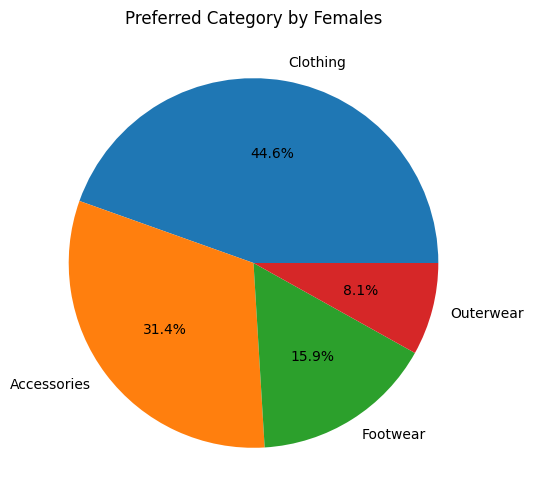

In [317]:
plt.figure(figsize=(6,6))
plt.pie(
   waffle_data_f.values(),
   labels = waffle_data_f.keys(),
   autopct='%1.1f%%'
)
plt.title('Preferred Category by Females')

plt.show()

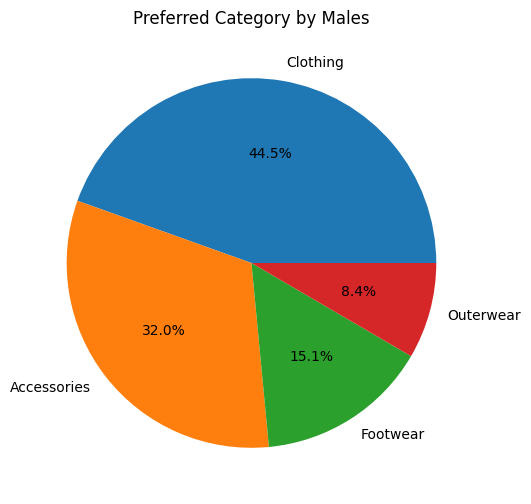

In [318]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [319]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = df[(df['Gender'] == 'Female') & (df['Category'] == 'Clothing')]
avg_cr_f = cr_f['Review Rating'].mean()

avg_cr_f

np.float64(3.7044964028776977)

In [320]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = df[(df['Gender'] == 'Male') & (df['Category'] == 'Clothing')]
avg_cr_m = cr_m['Review Rating'].mean()

avg_cr_m

np.float64(3.7319220999153258)

In [321]:
avg_cr_f,avg_cr_m

(np.float64(3.7044964028776977), np.float64(3.7319220999153258))

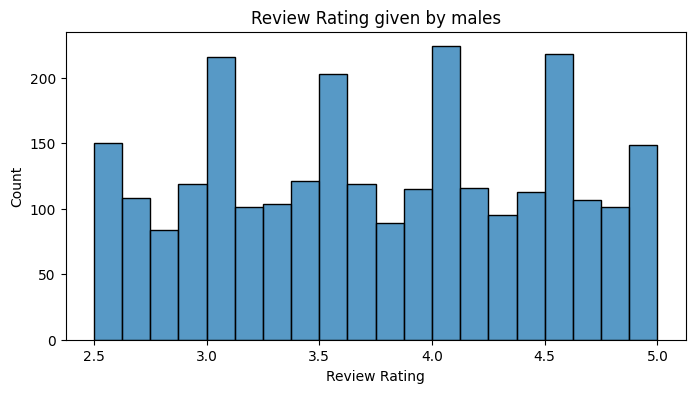

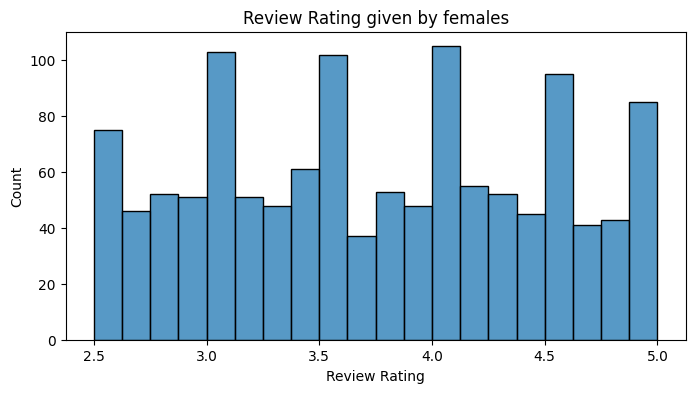

In [322]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8,4))
sns.histplot(
    data=female_df,
    x='Review Rating',
    bins=20
)
plt.title('Review Rating given by females')
plt.show()

In [323]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m = male_df['Review Rating'].value_counts()
cr_m


Review Rating
3.4    121
4.6    120
4.0    119
3.7    119
2.9    119
4.2    116
3.9    115
4.4    113
3.0    112
2.7    108
4.7    107
2.6    106
4.9    106
4.1    105
3.5    105
3.3    104
3.1    104
3.2    101
4.8    101
4.5     98
3.6     98
4.3     95
3.8     89
2.8     84
2.5     44
5.0     43
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [324]:
df['Gender']

0         Male
1         Male
2         Male
3         Male
4         Male
         ...  
3895    Female
3896    Female
3897    Female
3898    Female
3899    Female
Name: Gender, Length: 3900, dtype: object

In [325]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = df[df['Gender']=='Male']['Purchase Amount (USD)'].sum()

# # TODO: sum Purchase Amount (USD) for females
f_tpa = df[df['Gender'] == 'Female']['Purchase Amount (USD)'].sum()

In [326]:
m_tpa, f_tpa

(np.int64(157890), np.int64(75191))

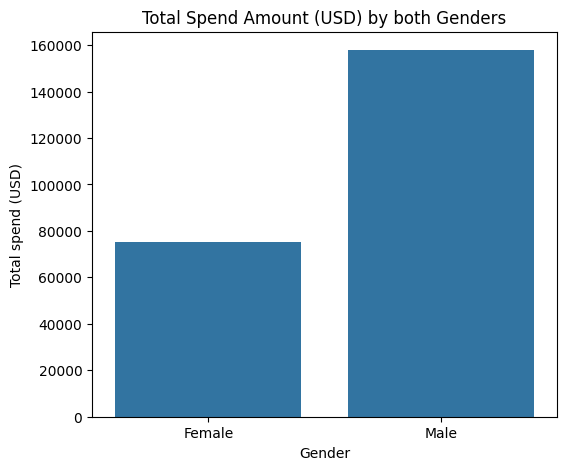

In [327]:
# TODO: plot total spend by gender with sns.barplot()
gender_spend = df.groupby('Gender')['Purchase Amount (USD)'].sum().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(
    data=gender_spend,
    x='Gender',
    y='Purchase Amount (USD)'
)

plt.title('Total Spend Amount (USD) by both Genders')
plt.ylabel('Total spend (USD)')
plt.show()

In [328]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = female_df[female_df['Category'] == 'Clothing']
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [329]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = male_df[male_df['Category'] == 'Clothing']
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [330]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = df['Promo Code Used'].value_counts().to_dict()
pcu

{'No': 2223, 'Yes': 1677}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

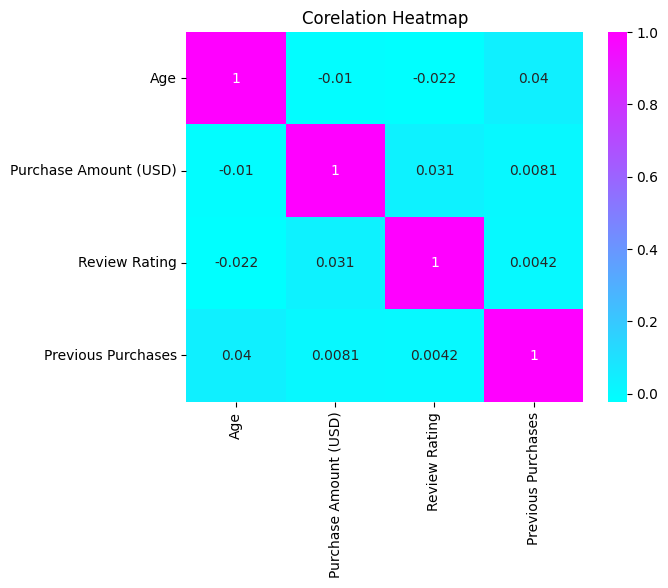

In [331]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='cool'
)

plt.title('Corelation Heatmap')
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [335]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
# df = pd.get_dummies(df, columns=[?], dtype=?)
# df.head()

df = pd.get_dummies(df,columns=['Gender','Size','Category'], dtype=int)
df.head()

,Customer ID,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,1,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,...,0,1,1,0,0,0,0,1,0,0
1,2,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,...,0,1,1,0,0,0,0,1,0,0
2,3,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,...,0,1,0,0,1,0,0,1,0,0
3,4,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,...,0,1,0,1,0,0,0,0,1,0
4,5,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,...,0,1,0,1,0,0,0,1,0,0


In [ ]:
%pip install scikit-learn

     ---------------------------------------- 11.2/11.2 MB 9.6 MB/s eta 0:00:00
     ------------------------------------- 309.1/309.1 KB 19.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\lenovo\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [333]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [334]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'], bins=3, labels=['Low','Medium','High'])
df['Amount_bin'].value_counts()



Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# Key insights
- Clothing is the most frequently purchased category for both genders in this dataset.
- The most purchased items differ somewhat between male and female customers, while the overall item counts remain distributed across many products.
- Total spending can be compared directly by gender using the bar chart; the difference reflects the observed sample, not a causal effect of gender.
- Review ratings are concentrated in a similar range for both genders, so the distributions should be interpreted alongside their mean values.
- Promo-code usage is summarized by `pcu`; its counts show how often each promo-code status appears in the dataset.

Caveat: correlation is not causation.